<a href="https://colab.research.google.com/github/raghavkarthikcse2025-coder/daa-lab/blob/main/Exp-5%20with%20outputs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

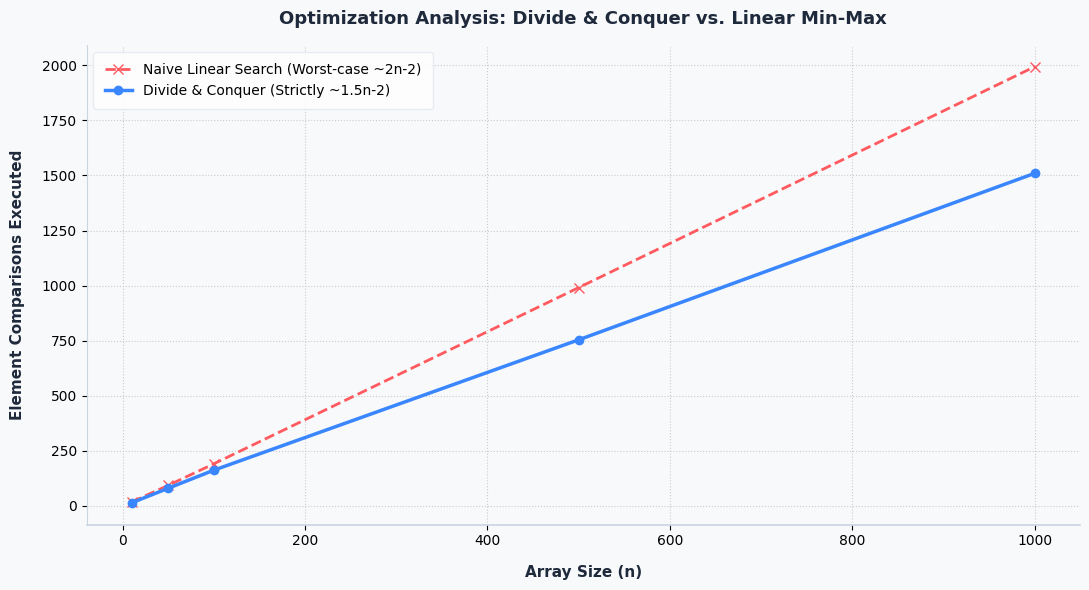

In [1]:
import random
import matplotlib.pyplot as plt

# --- Simplified Search Algorithms (No Global State) ---

def min_max_dc(arr, low, high):
    # Base Case 1: Only one element
    if low == high:
        return arr[low], arr[low], 0

    # Base Case 2: Only two elements
    if high == low + 1:
        if arr[low] < arr[high]:
            return arr[low], arr[high], 1
        return arr[high], arr[low], 1

    # Recursive Case: Divide into halves
    mid = (low + high) // 2
    l_min, l_max, l_comps = min_max_dc(arr, low, mid)
    r_min, r_max, r_comps = min_max_dc(arr, mid + 1, high)

    # 2 additional comparisons to merge the split results
    final_min = l_min if l_min < r_min else r_min
    final_max = l_max if l_max > r_max else r_max

    return final_min, final_max, l_comps + r_comps + 2

def min_max_naive(arr):
    if not arr:
        return None, None, 0

    mn = mx = arr[0]
    comps = 0

    for x in arr[1:]:
        comps += 1
        if x < mn:
            mn = x
        else:
            comps += 1  # Only executed if the first check fails
            if x > mx:
                mx = x

    return mn, mx, comps

# --- Benchmarking Setup ---
sizes = [10, 50, 100, 500, 1000]
results = {"Naive": [], "D&C": []}

for size in sizes:
    test_arr = [random.randint(1, 100000) for _ in range(size)]

    # Run algorithms and capture comparison statistics dynamically
    _, _, dc_comps = min_max_dc(test_arr, 0, len(test_arr) - 1)
    _, _, naive_comps = min_max_naive(test_arr)

    results["D&C"].append(dc_comps)
    results["Naive"].append(naive_comps)

# --- Ultra-Polished Visual Plotting ---
fig, ax = plt.subplots(figsize=(11, 6), dpi=100)
fig.patch.set_facecolor('#F8F9FA')  # Light neutral modern background
ax.set_facecolor('#F8F9FA')

# High-contrast color choices
colors = {
    "Naive": "#FF5A5F",  # Coral Red
    "D&C": "#3A86FF"     # Electric Blue
}

# Plot comparison curves
ax.plot(
    sizes, results["Naive"],
    marker='x', markersize=7, color=colors["Naive"], linestyle='--',
    linewidth=2, label='Naive Linear Search (Worst-case ~2n-2)'
)
ax.plot(
    sizes, results["D&C"],
    marker='o', markersize=6, color=colors["D&C"],
    linewidth=2.5, label='Divide & Conquer (Strictly ~1.5n-2)'
)

# Customizing Typography & Labels
ax.set_title('Optimization Analysis: Divide & Conquer vs. Linear Min-Max',
             fontsize=13, fontweight='bold', pad=15, color='#1E293B')
ax.set_xlabel('Array Size (n)', fontsize=11, fontweight='semibold', labelpad=12, color='#1E293B')
ax.set_ylabel('Element Comparisons Executed', fontsize=11, fontweight='semibold', labelpad=12, color='#1E293B')

# Clean minimalist borders
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#CBD5E1')
ax.spines['bottom'].set_linewidth(1.2)

# Soft layout grids
ax.grid(axis='both', linestyle=':', linewidth=0.8, color='#CCCCCC')

# Sophisticated legend positioning
ax.legend(
    frameon=True, facecolor='#FFFFFF', edgecolor='#E2E8F0',
    loc='upper left', fontsize=10, borderpad=0.8
)

plt.tight_layout()
plt.show()